In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/beyondblue_data_flattened_transformers_twitter_english_enriched.csv")

# Inspect structure
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42961 entries, 0 to 42960
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   parent_post_id  42961 non-null  int64  
 1   user_id         42961 non-null  object 
 2   role            42961 non-null  object 
 3   text            42960 non-null  object 
 4   date            42961 non-null  object 
 5   category        42961 non-null  object 
 6   sentiment_dist  42961 non-null  object 
 7   valence_s       42961 non-null  float64
 8   sentiment_top   42961 non-null  object 
 9   sentiment_conf  42961 non-null  float64
 10  emotion_dist    42961 non-null  object 
 11  valence_e       42961 non-null  float64
 12  arousal_e       42961 non-null  float64
 13  emotion_top     42961 non-null  object 
 14  emotion_conf    42961 non-null  float64
dtypes: float64(5), int64(1), object(9)
memory usage: 4.9+ MB


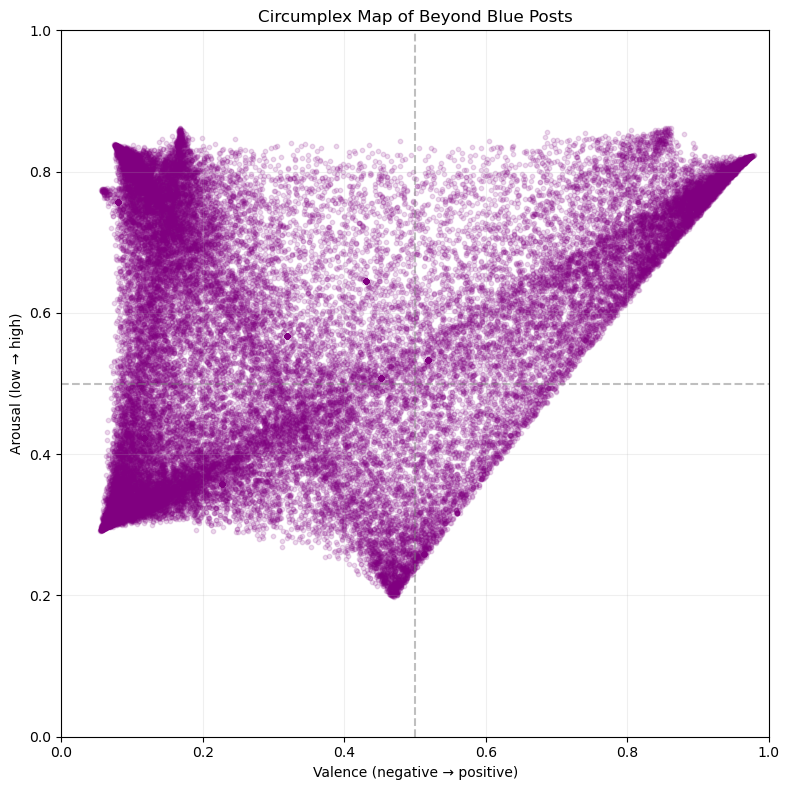

In [12]:
plt.figure(figsize=(8,8))
plt.scatter(df['valence_e'], df['arousal_e'], alpha=0.15, s=10, c="purple")

plt.axhline(0.5, color='grey', linestyle='--', alpha=0.5)
plt.axvline(0.5, color='grey', linestyle='--', alpha=0.5)

plt.title("Circumplex Map of Beyond Blue Posts")
plt.xlabel("Valence (negative → positive)")
plt.ylabel("Arousal (low → high)")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [13]:
def classify_circumplex(v, a):
    if v >= 0.5 and a >= 0.5:
        return "Positive-Activated (Energy)"
    elif v < 0.5 and a >= 0.5:
        return "Negative-Activated (Anxiety)"
    elif v < 0.5 and a < 0.5:
        return "Negative-Deactivated (Depression)"
    else:
        return "Positive-Deactivated (Calm/Relief)"

df["circumplex_quad"] = df.apply(lambda r: classify_circumplex(r['valence_e'], r['arousal_e']), axis=1)
df['circumplex_quad'].value_counts()

circumplex_quad
Negative-Deactivated (Depression)     16237
Negative-Activated (Anxiety)          14012
Positive-Activated (Energy)           10709
Positive-Deactivated (Calm/Relief)     2003
Name: count, dtype: int64

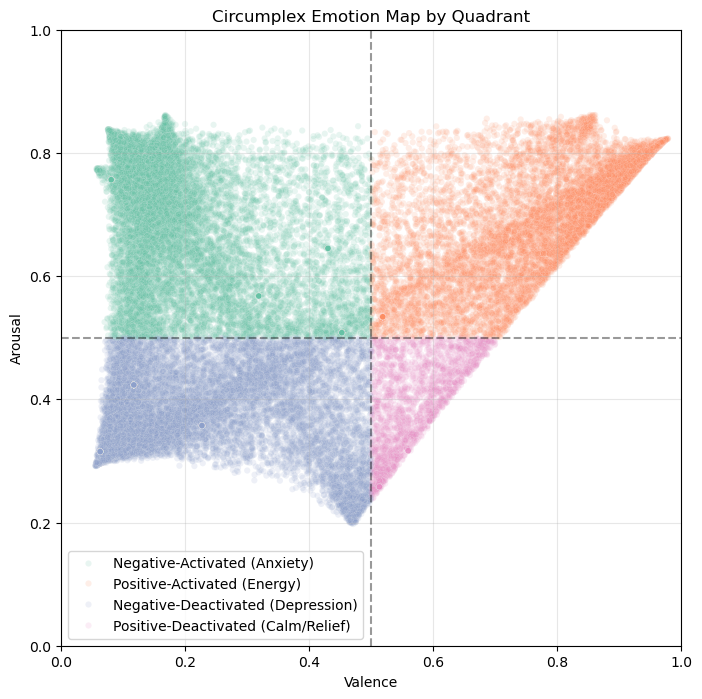

In [14]:
plt.figure(figsize=(8,8))
sns.scatterplot(
    data=df,
    x='valence_e',
    y='arousal_e',
    hue='circumplex_quad',
    palette='Set2',
    alpha=0.15,
    s=20
)

plt.axhline(0.5, color='black', linestyle='--', alpha=0.4)
plt.axvline(0.5, color='black', linestyle='--', alpha=0.4)

plt.title("Circumplex Emotion Map by Quadrant")
plt.xlabel("Valence")
plt.ylabel("Arousal")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

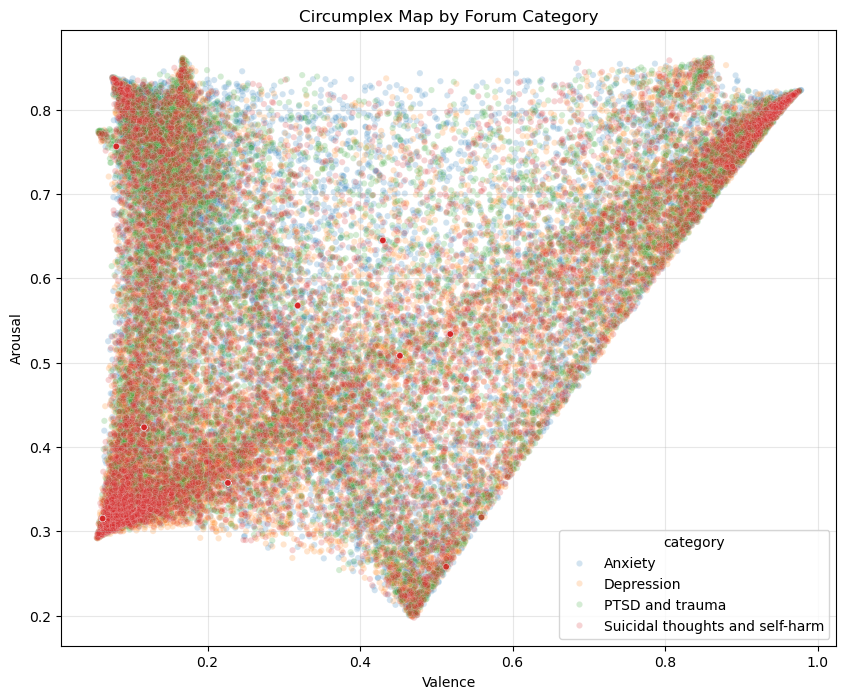

In [15]:
plt.figure(figsize=(10,8))
sns.scatterplot(
    data=df,
    x='valence_e',
    y='arousal_e',
    hue='category',
    alpha=0.2,
    s=20,
    palette='tab10'
)
plt.title("Circumplex Map by Forum Category")
plt.xlabel("Valence")
plt.ylabel("Arousal")
plt.grid(alpha=0.3)
plt.show()

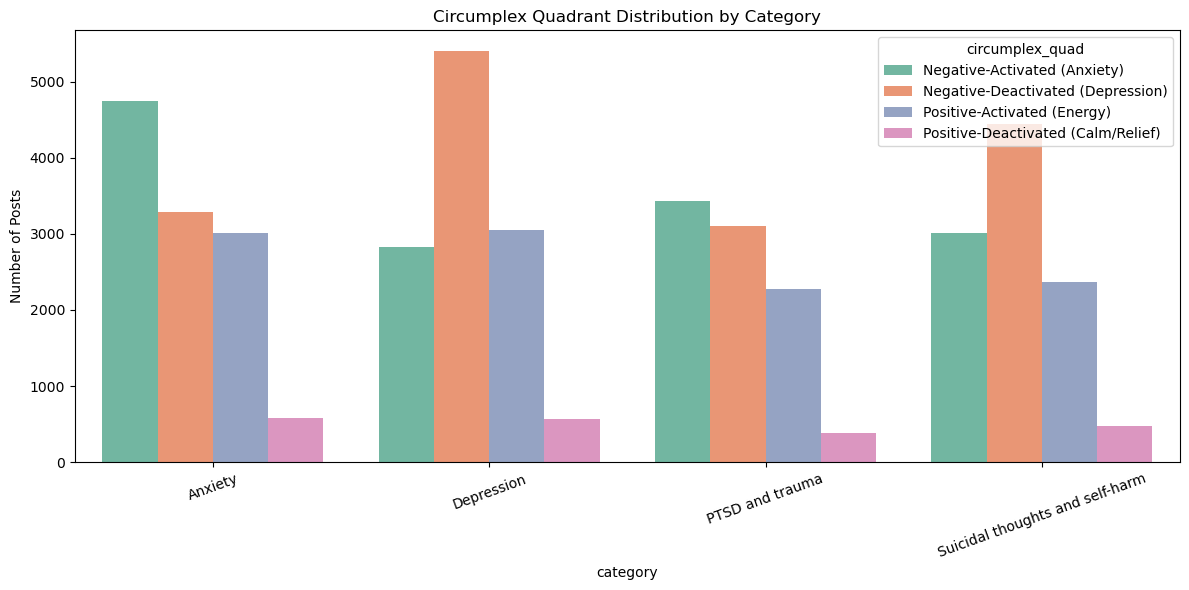

In [16]:
quad_counts = df.groupby(['category','circumplex_quad']).size().reset_index(name='count')

plt.figure(figsize=(12,6))
sns.barplot(
    data=quad_counts,
    x='category',
    y='count',
    hue='circumplex_quad',
    palette='Set2'
)
plt.title("Circumplex Quadrant Distribution by Category")
plt.ylabel("Number of Posts")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()